# Climate Change Sentiment Analysis 

This notebook provides a comprehensive analysis of climate change discussions on social media, including:
- Data exploration and understanding
- Data cleaning and preprocessing
- Advanced visualizations
- Multiple machine learning models for sentiment prediction
- Feature engineering and model evaluation
- Code explaination on each lines wherever necessary

In [2]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from textblob import TextBlob   # for sentiment analysis
import re                       # for regular expressions
from collections import Counter # for counting hash tags
from wordcloud import WordCloud # for generating word clouds

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix   # for model evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder  # for data preprocessing

plt.style.use('seaborn-v0_8')   # setting plot style
sns.set_palette("husl") # setting seaborn color palette
pd.set_option('display.max_columns', None)  # To display all columns in pandas dataframe

## 1. Data Loading and Initial Exploration

In [3]:
df = pd.read_csv('climate_nasa.csv')

print("Dataset Shape:", df.shape)
print("\n=== Dataset Info ===")
df.info()

# print("\n=== First 5 rows ===")
# display(df.head())

# print("\n=== Statistical Summary ===")
# display(df.describe(include='all'))

Dataset Shape: (522, 5)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


## 2. Data Quality Assessment

In [5]:

missing_data = df.isnull().sum()
# missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data
    # ,'Missing Percentage': missing_percent
})

print("=== Missing Data Analysis ===")
display(missing_df[missing_df['Missing Count'] > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Data type analysis
print("\n=== Data Types ===")
print(df.dtypes)

# Unique values in categorical columns
print("\n=== Unique Values ===")
for col in df.select_dtypes(include=['object']).columns:
    if col != 'text':  # Skip text column as it has too many unique values
        print(f"{col}: {df[col].nunique()} unique values")

=== Missing Data Analysis ===


,Missing Count
commentsCount,278
text,18



Duplicate rows: 0

=== Data Types ===
date              object
likesCount         int64
profileName       object
commentsCount    float64
text              object
dtype: object

=== Unique Values ===
date: 522 unique values
profileName: 483 unique values


## 3. Enhanced Data Cleaning and Preprocessing

In [6]:
# Create a copy for processing
df_clean = df.copy()

# Convert date column to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Extract temporal features
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
df_clean['hour'] = df_clean['date'].dt.hour
df_clean['month_year'] = df_clean['date'].dt.to_period('M').astype(str)

# Handle missing values
df_clean['text'] = df_clean['text'].fillna('')
df_clean['commentsCount'] = df_clean['commentsCount'].fillna(0)

# Enhanced text cleaning function
def advanced_text_cleaning(text):
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply text cleaning
df_clean['cleaned_text'] = df_clean['text'].apply(advanced_text_cleaning)

# Create additional features
df_clean['text_length'] = df_clean['cleaned_text'].str.len()
df_clean['word_count'] = df_clean['cleaned_text'].str.split().str.len()
df_clean['has_text'] = (df_clean['text_length'] > 0).astype(int)

# Remove rows with empty text for sentiment analysis
df_analysis = df_clean[df_clean['text_length'] > 0].copy()

print(f"Original dataset: {len(df)} rows")
print(f"After cleaning: {len(df_analysis)} rows with text")
print(f"Removed {len(df) - len(df_analysis)} rows with empty text")

Original dataset: 522 rows
After cleaning: 488 rows with text
Removed 34 rows with empty text


## 4. Exploratory Data Analysis

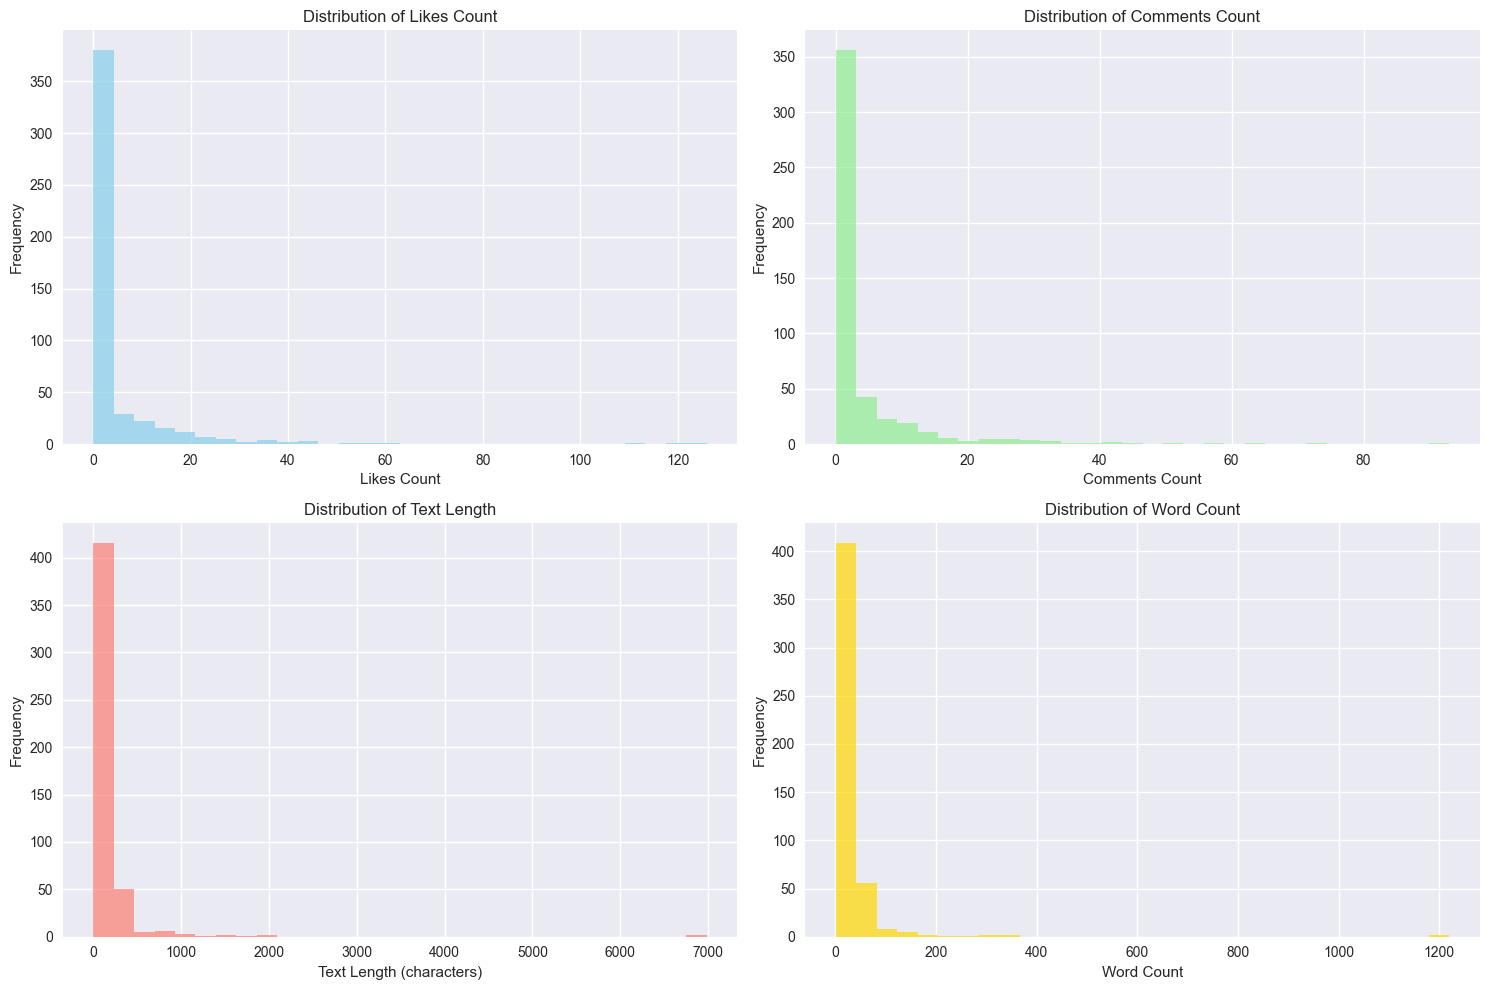


=== Key Statistics ===
Average likes per post: 5.02
Average comments per post: 4.32
Average text length: 178.05 characters
Average word count: 32.12 words


In [7]:
# Basic statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Likes distribution
axes[0,0].hist(df_analysis['likesCount'], bins=30, alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribution of Likes Count')
axes[0,0].set_xlabel('Likes Count')
axes[0,0].set_ylabel('Frequency')

# Comments distribution
axes[0,1].hist(df_analysis['commentsCount'], bins=30, alpha=0.7, color='lightgreen')
axes[0,1].set_title('Distribution of Comments Count')
axes[0,1].set_xlabel('Comments Count')
axes[0,1].set_ylabel('Frequency')

# Text length distribution
axes[1,0].hist(df_analysis['text_length'], bins=30, alpha=0.7, color='salmon')
axes[1,0].set_title('Distribution of Text Length')
axes[1,0].set_xlabel('Text Length (characters)')
axes[1,0].set_ylabel('Frequency')

# Word count distribution
axes[1,1].hist(df_analysis['word_count'], bins=30, alpha=0.7, color='gold')
axes[1,1].set_title('Distribution of Word Count')
axes[1,1].set_xlabel('Word Count')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Key Statistics ===")
print(f"Average likes per post: {df_analysis['likesCount'].mean():.2f}")
print(f"Average comments per post: {df_analysis['commentsCount'].mean():.2f}")
print(f"Average text length: {df_analysis['text_length'].mean():.2f} characters")
print(f"Average word count: {df_analysis['word_count'].mean():.2f} words")

## 5. Advanced Sentiment Analysis

=== Sentiment Distribution ===
Neutral: 273 (55.94%)
Positive: 150 (30.74%)
Negative: 65 (13.32%)


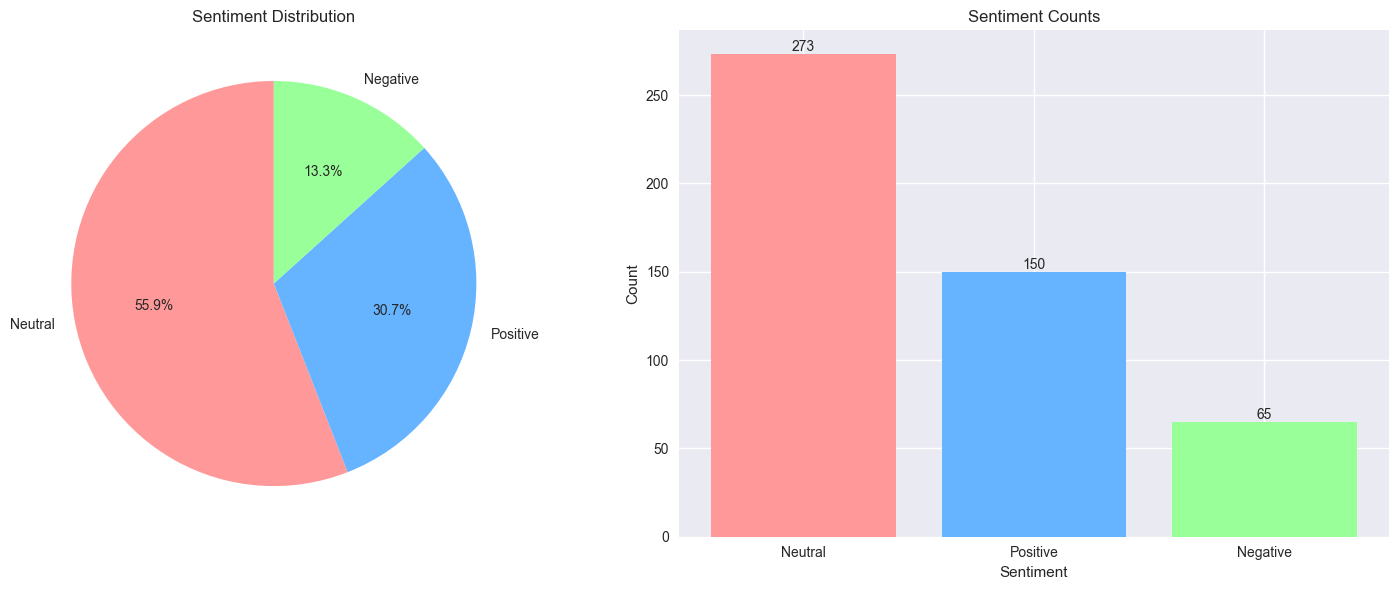

In [8]:
# Enhanced sentiment analysis function
def get_sentiment_scores(text):
    if not text or len(text.strip()) == 0:
        return 0, 0, 'Neutral'
    
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    
    # More nuanced sentiment classification
    if polarity > 0.1:
        sentiment = 'Positive'
    elif polarity < -0.1:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
    
    return polarity, subjectivity, sentiment

# Apply sentiment analysis
sentiment_data = df_analysis['cleaned_text'].apply(get_sentiment_scores)
df_analysis['polarity'] = sentiment_data.apply(lambda x: x[0])
df_analysis['subjectivity'] = sentiment_data.apply(lambda x: x[1])
df_analysis['sentiment'] = sentiment_data.apply(lambda x: x[2])

# Sentiment distribution
sentiment_counts = df_analysis['sentiment'].value_counts()
sentiment_props = df_analysis['sentiment'].value_counts(normalize=True)

print("=== Sentiment Distribution ===")
for sentiment, count in sentiment_counts.items():
    prop = sentiment_props[sentiment]
    print(f"{sentiment}: {count} ({prop:.2%})")

# Visualize sentiment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('Sentiment Distribution')

# Bar chart
bars = ax2.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
ax2.set_title('Sentiment Counts')
ax2.set_ylabel('Count')
ax2.set_xlabel('Sentiment')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 6. Temporal Analysis

In [7]:
# Time series analysis
monthly_data = df_analysis.groupby('month_year').agg({
    'likesCount': ['mean', 'sum', 'count'],
    'commentsCount': ['mean', 'sum'],
    'polarity': 'mean',
    'sentiment': lambda x: (x == 'Positive').mean()
}).round(2)

monthly_data.columns = ['avg_likes', 'total_likes', 'post_count', 
                       'avg_comments', 'total_comments', 'avg_polarity', 'positive_ratio']
monthly_data = monthly_data.reset_index()
monthly_data['date'] = pd.to_datetime(monthly_data['month_year'])

# Create interactive time series plots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Posts Over Time', 'Average Sentiment Over Time', 
                   'Engagement Over Time', 'Positive Sentiment Ratio'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": True}, {"secondary_y": False}]]
)

# Posts over time
fig.add_trace(
    go.Scatter(x=monthly_data['date'], y=monthly_data['post_count'],
               mode='lines+markers', name='Post Count'),
    row=1, col=1
)

# Average sentiment over time
fig.add_trace(
    go.Scatter(x=monthly_data['date'], y=monthly_data['avg_polarity'],
               mode='lines+markers', name='Avg Polarity', line=dict(color='green')),
    row=1, col=2
)

# Engagement over time (likes and comments)
fig.add_trace(
    go.Scatter(x=monthly_data['date'], y=monthly_data['avg_likes'],
               mode='lines+markers', name='Avg Likes', line=dict(color='blue')),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=monthly_data['date'], y=monthly_data['avg_comments'],
               mode='lines+markers', name='Avg Comments', line=dict(color='red')),
    row=2, col=1, secondary_y=True
)

# Positive sentiment ratio
fig.add_trace(
    go.Scatter(x=monthly_data['date'], y=monthly_data['positive_ratio'],
               mode='lines+markers', name='Positive Ratio', line=dict(color='orange')),
    row=2, col=2
)

fig.update_layout(height=800, title_text="Climate Change Discussion Trends Over Time")
fig.show()

## 7. Advanced Text Analysis

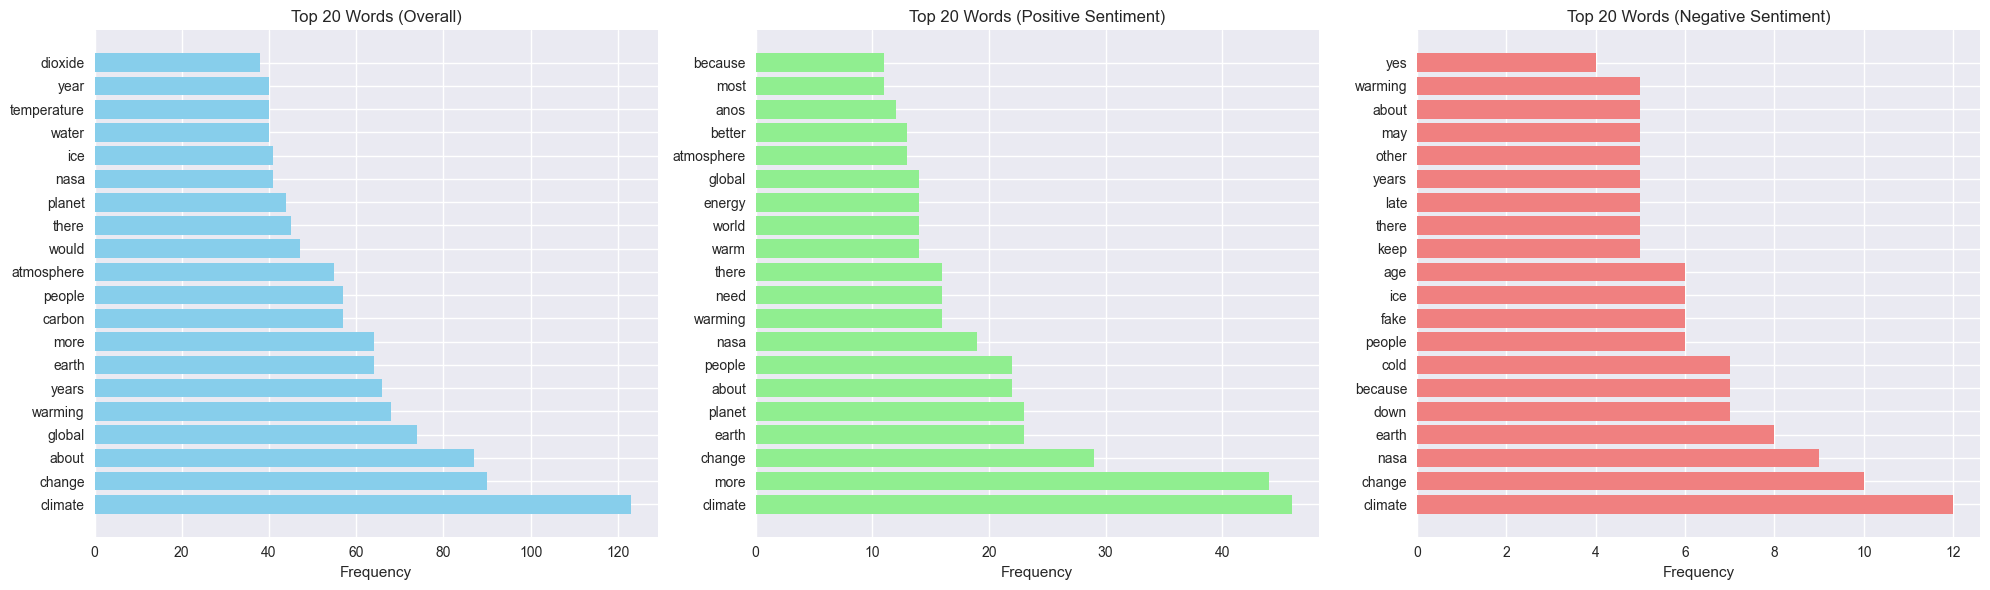

=== Top 10 Words Overall ===
climate: 123
change: 90
about: 87
global: 74
warming: 68
years: 66
earth: 64
more: 64
carbon: 57
people: 57


In [9]:
# Word frequency analysis
def get_top_words(texts, n=20, min_length=3):
    # Combine all texts
    all_text = ' '.join(texts)
    
    # Split into words and filter
    words = [word for word in all_text.split() 
             if len(word) >= min_length and word.isalpha()]
    
    # Common stop words to exclude
    stop_words = {'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 'can', 
                  'had', 'her', 'was', 'one', 'our', 'out', 'day', 'get', 'has', 
                  'him', 'his', 'how', 'man', 'new', 'now', 'old', 'see', 'two', 
                  'way', 'who', 'boy', 'did', 'its', 'let', 'put', 'say', 'she', 
                  'too', 'use', 'that', 'with', 'have', 'this', 'will', 'your', 
                  'from', 'they', 'know', 'want', 'been', 'good', 'much', 'some', 
                  'time', 'very', 'when', 'come', 'here', 'just', 'like', 'long', 
                  'make', 'many', 'over', 'such', 'take', 'than', 'them', 'well', 
                  'were', 'what'}
    
    # Filter out stop words
    filtered_words = [word for word in words if word.lower() not in stop_words]
    
    return Counter(filtered_words).most_common(n)

# Get top words overall and by sentiment
top_words_overall = get_top_words(df_analysis['cleaned_text'])
top_words_positive = get_top_words(df_analysis[df_analysis['sentiment'] == 'Positive']['cleaned_text'])
top_words_negative = get_top_words(df_analysis[df_analysis['sentiment'] == 'Negative']['cleaned_text'])

# Visualize top words
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Overall top words
words, counts = zip(*top_words_overall)
axes[0].barh(range(len(words)), counts, color='skyblue')
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].set_title('Top 20 Words (Overall)')
axes[0].set_xlabel('Frequency')

# Positive sentiment words
if top_words_positive:
    words_pos, counts_pos = zip(*top_words_positive)
    axes[1].barh(range(len(words_pos)), counts_pos, color='lightgreen')
    axes[1].set_yticks(range(len(words_pos)))
    axes[1].set_yticklabels(words_pos)
    axes[1].set_title('Top 20 Words (Positive Sentiment)')
    axes[1].set_xlabel('Frequency')

# Negative sentiment words
if top_words_negative:
    words_neg, counts_neg = zip(*top_words_negative)
    axes[2].barh(range(len(words_neg)), counts_neg, color='lightcoral')
    axes[2].set_yticks(range(len(words_neg)))
    axes[2].set_yticklabels(words_neg)
    axes[2].set_title('Top 20 Words (Negative Sentiment)')
    axes[2].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

# Print top words
print("=== Top 10 Words Overall ===")
for word, count in top_words_overall[:10]:
    print(f"{word}: {count}")

## 8. Engagement Analysis

=== Engagement by Sentiment ===


likesCount               commentsCount               text_length  \
                mean median    std          mean median    std        mean   
sentiment                                                                    
Negative        5.94    1.0  11.64          5.68    1.0  11.05      113.55   
Neutral         4.14    1.0  10.99          3.70    0.0   8.97      186.93   
Positive        6.23    1.0  14.88          4.86    1.0  10.32      189.83   

                 word_count         
          median       mean median  
sentiment                           
Negative   108.0      21.08   21.0  
Neutral     77.0      33.30   14.0  
Positive   101.5      34.76   19.0

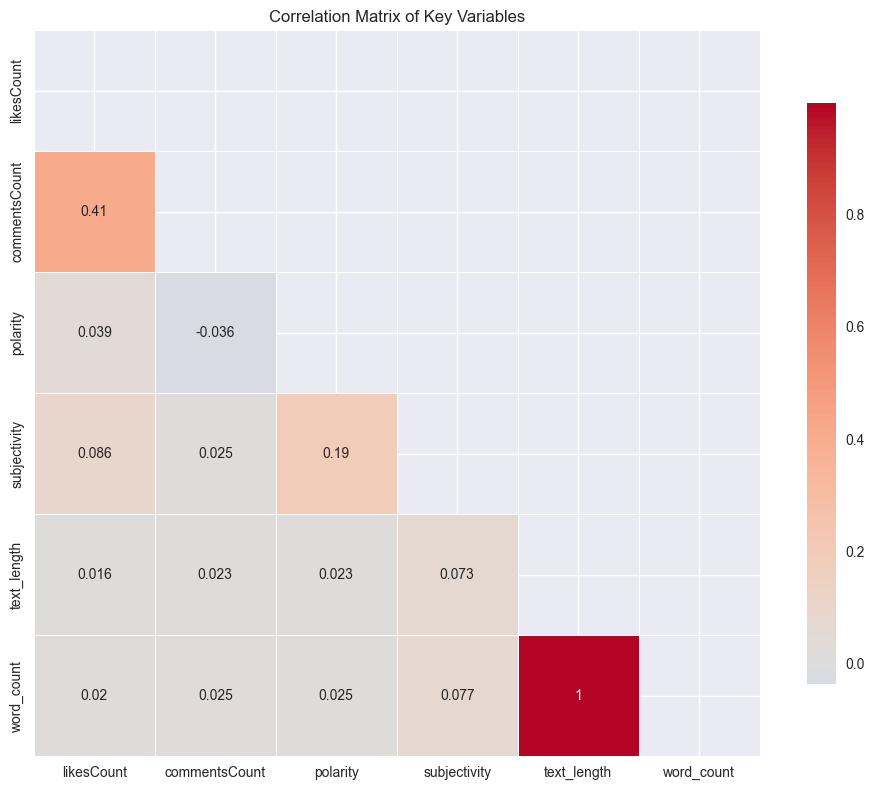

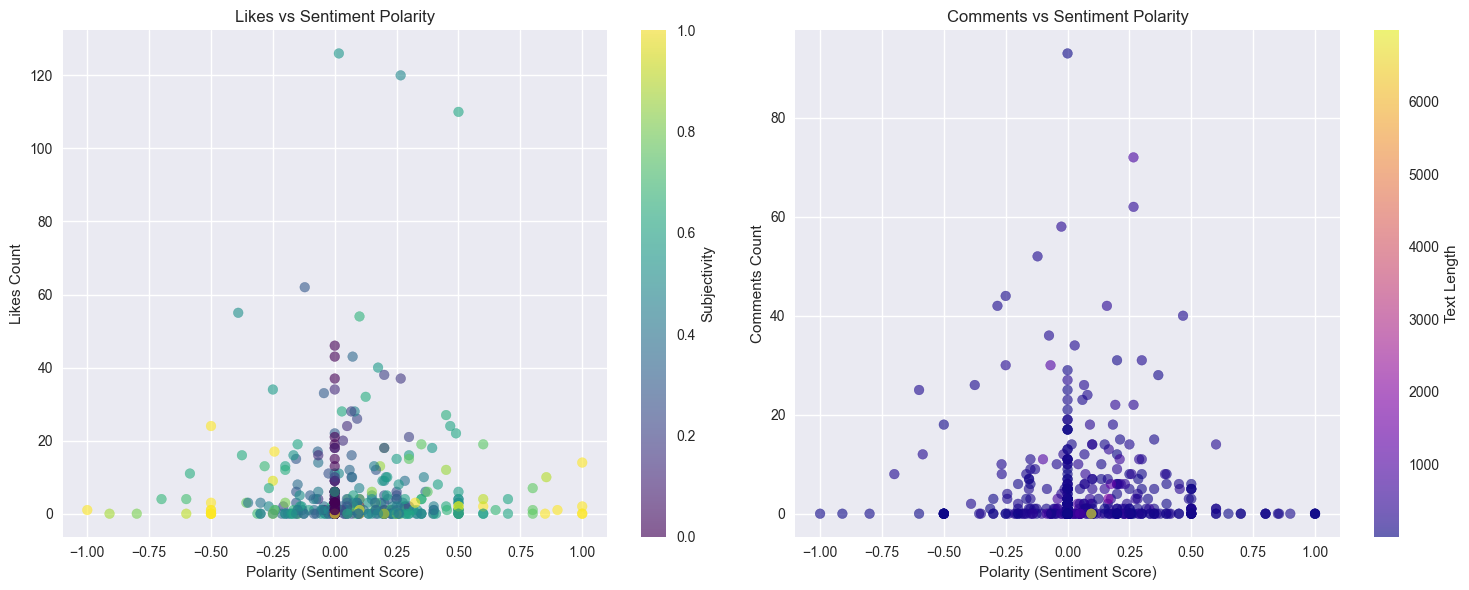

In [10]:
# Engagement by sentiment
engagement_by_sentiment = df_analysis.groupby('sentiment').agg({
    'likesCount': ['mean', 'median', 'std'],
    'commentsCount': ['mean', 'median', 'std'],
    'text_length': ['mean', 'median'],
    'word_count': ['mean', 'median']
}).round(2)

print("=== Engagement by Sentiment ===")
display(engagement_by_sentiment)


# Correlation analysis
correlation_cols = ['likesCount', 'commentsCount', 'polarity', 'subjectivity', 
                   'text_length', 'word_count']
correlation_matrix = df_analysis[correlation_cols].corr()

# Visualize correlations
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

# Engagement vs sentiment scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Likes vs Polarity
scatter = axes[0].scatter(df_analysis['polarity'], df_analysis['likesCount'], 
                         c=df_analysis['subjectivity'], cmap='viridis', alpha=0.6)
axes[0].set_xlabel('Polarity (Sentiment Score)')
axes[0].set_ylabel('Likes Count')
axes[0].set_title('Likes vs Sentiment Polarity')
plt.colorbar(scatter, ax=axes[0], label='Subjectivity')

# Comments vs Polarity
scatter2 = axes[1].scatter(df_analysis['polarity'], df_analysis['commentsCount'], 
                          c=df_analysis['text_length'], cmap='plasma', alpha=0.6)
axes[1].set_xlabel('Polarity (Sentiment Score)')
axes[1].set_ylabel('Comments Count')
axes[1].set_title('Comments vs Sentiment Polarity')
plt.colorbar(scatter2, ax=axes[1], label='Text Length')

plt.tight_layout()
plt.show()

## 9. Feature Engineering for Machine Learning

In [10]:
# Create additional features
df_ml = df_analysis.copy()

# Engagement rate features
df_ml['engagement_rate'] = (df_ml['likesCount'] + df_ml['commentsCount']) / (df_ml['text_length'] + 1)
df_ml['likes_per_word'] = df_ml['likesCount'] / (df_ml['word_count'] + 1)
df_ml['comments_per_word'] = df_ml['commentsCount'] / (df_ml['word_count'] + 1)

# Categorical features
df_ml['is_weekend'] = df_ml['day_of_week'].isin([5, 6]).astype(int)
df_ml['time_of_day'] = pd.cut(df_ml['hour'], bins=[0, 6, 12, 18, 24], 
                             labels=['Night', 'Morning', 'Afternoon', 'Evening'])

# Text-based features
df_ml['has_question'] = df_ml['text'].str.contains('\?', na=False).astype(int)
df_ml['has_exclamation'] = df_ml['text'].str.contains('!', na=False).astype(int)
df_ml['has_url'] = df_ml['text'].str.contains('http|www', na=False).astype(int)

# Sentiment intensity categories
df_ml['sentiment_intensity'] = pd.cut(df_ml['polarity'].abs(), 
                                     bins=[0, 0.1, 0.3, 0.6, 1.0],
                                     labels=['Neutral', 'Mild', 'Moderate', 'Strong'])

print("=== New Features Created ===")
new_features = ['engagement_rate', 'likes_per_word', 'comments_per_word', 
               'is_weekend', 'time_of_day', 'has_question', 'has_exclamation', 
               'has_url', 'sentiment_intensity']

for feature in new_features:
    print(f"{feature}: {df_ml[feature].dtype}")

# Display feature statistics
print("\n=== Feature Statistics ===")
display(df_ml[['engagement_rate', 'likes_per_word', 'comments_per_word']].describe())

=== New Features Created ===
engagement_rate: float64
likes_per_word: float64
comments_per_word: float64
is_weekend: int64
time_of_day: category
has_question: int64
has_exclamation: int64
has_url: int64
sentiment_intensity: category

=== Feature Statistics ===


,engagement_rate,likes_per_word,comments_per_word
count,488.000000,488.000000,488.000000
mean,0.099879,0.241363,0.238466
std,0.249225,0.595762,0.934229
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.025158,0.042705,0.000000
75%,0.106961,0.250000,0.200000
max,3.958333,7.333333,18.600000


## 10. Machine Learning Models

In [11]:
# Prepare data for machine learning
# Remove rows with missing target values
ml_data = df_ml.dropna(subset=['likesCount', 'commentsCount']).copy()

# Select features for modeling
feature_cols = ['polarity', 'subjectivity', 'text_length', 'word_count', 
               'commentsCount', 'year', 'month', 'day_of_week', 'hour',
               'is_weekend', 'has_question', 'has_exclamation', 'has_url']

# Prepare features and targets
X = ml_data[feature_cols].copy()
y_likes = ml_data['likesCount']
y_sentiment = ml_data['sentiment']

# Handle any remaining missing values
X = X.fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Dataset shape for ML: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target distribution (sentiment): {y_sentiment.value_counts()}")

Dataset shape for ML: (488, 13)
Features: ['polarity', 'subjectivity', 'text_length', 'word_count', 'commentsCount', 'year', 'month', 'day_of_week', 'hour', 'is_weekend', 'has_question', 'has_exclamation', 'has_url']
Target distribution (sentiment): sentiment
Neutral     273
Positive    150
Negative     65
Name: count, dtype: int64


### 10.1 Regression Models (Predicting Likes Count)

In [12]:
# Split data for regression
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_likes, test_size=0.2, random_state=42
)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale')
}

# Train and evaluate models
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'MSE': mse,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std(),
        'predictions': y_pred
    }
    
    print(f"\n=== {name} Results ===")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Feature importance for Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importance (Random Forest) ===")
display(feature_importance.head(10))


=== Linear Regression Results ===
MSE: 130.1839
R²: 0.3578
CV R² (mean ± std): 0.1025 ± 0.0706

=== Random Forest Results ===
MSE: 176.4461
R²: 0.1296
CV R² (mean ± std): -0.1416 ± 0.4238

=== SVR Results ===
MSE: 201.2353
R²: 0.0073
CV R² (mean ± std): 0.0157 ± 0.0704

=== Feature Importance (Random Forest) ===


,feature,importance
4,commentsCount,0.290029
0,polarity,0.158287
1,subjectivity,0.147199
2,text_length,0.103018
8,hour,0.096781
3,word_count,0.090782
5,year,0.038107
6,month,0.027989
7,day_of_week,0.026443
10,has_question,0.009822


### 10.2 Classification Models (Predicting Sentiment)


=== Logistic Regression Classification Results ===
Accuracy: 0.9592
CV Accuracy (mean ± std): 0.9462 ± 0.0096

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.85      0.92        13
     Neutral       0.93      1.00      0.96        55
    Positive       1.00      0.93      0.97        30

    accuracy                           0.96        98
   macro avg       0.98      0.93      0.95        98
weighted avg       0.96      0.96      0.96        98


=== Random Forest Classification Results ===
Accuracy: 1.0000
CV Accuracy (mean ± std): 0.9923 ± 0.0063

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        13
     Neutral       1.00      1.00      1.00        55
    Positive       1.00      1.00      1.00        30

    accuracy                           1.00        98
   macro avg       1.00      1.00      1.00        98
weighted avg       1.00      

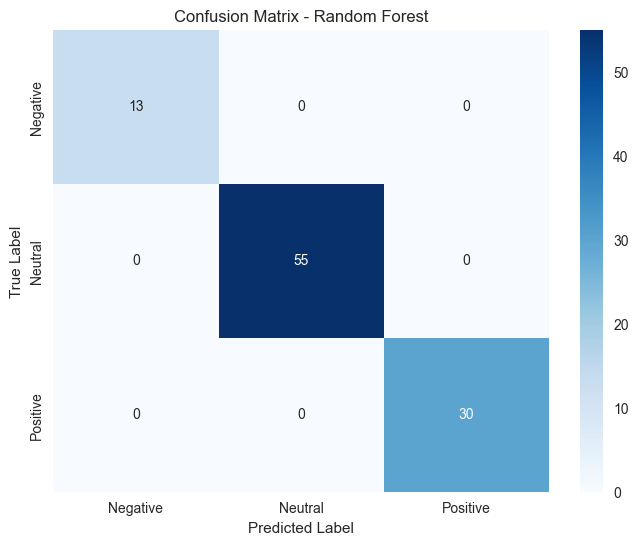


Best Classification Model: Random Forest
Best Accuracy: 1.0000


In [13]:
# Prepare data for classification
le = LabelEncoder()
y_sentiment_encoded = le.fit_transform(y_sentiment)

# Split data for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_sentiment_encoded, test_size=0.2, random_state=42, stratify=y_sentiment_encoded
)

# Initialize classification models
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

# Train and evaluate classification models
clf_results = {}

for name, model in clf_models.items():
    # Train model
    model.fit(X_train_clf, y_train_clf)
    
    # Make predictions
    y_pred_clf = model.predict(X_test_clf)
    
    # Calculate accuracy
    accuracy = model.score(X_test_clf, y_test_clf)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_clf, y_train_clf, cv=5)
    
    clf_results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred_clf
    }
    
    print(f"\n=== {name} Classification Results ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"CV Accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test_clf, y_pred_clf, 
                              target_names=le.classes_))

# Best model confusion matrix
best_clf_model = max(clf_results.keys(), key=lambda k: clf_results[k]['accuracy'])
best_predictions = clf_results[best_clf_model]['predictions']

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_clf, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_clf_model}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\nBest Classification Model: {best_clf_model}")
print(f"Best Accuracy: {clf_results[best_clf_model]['accuracy']:.4f}")

## 11. Model Performance Visualization

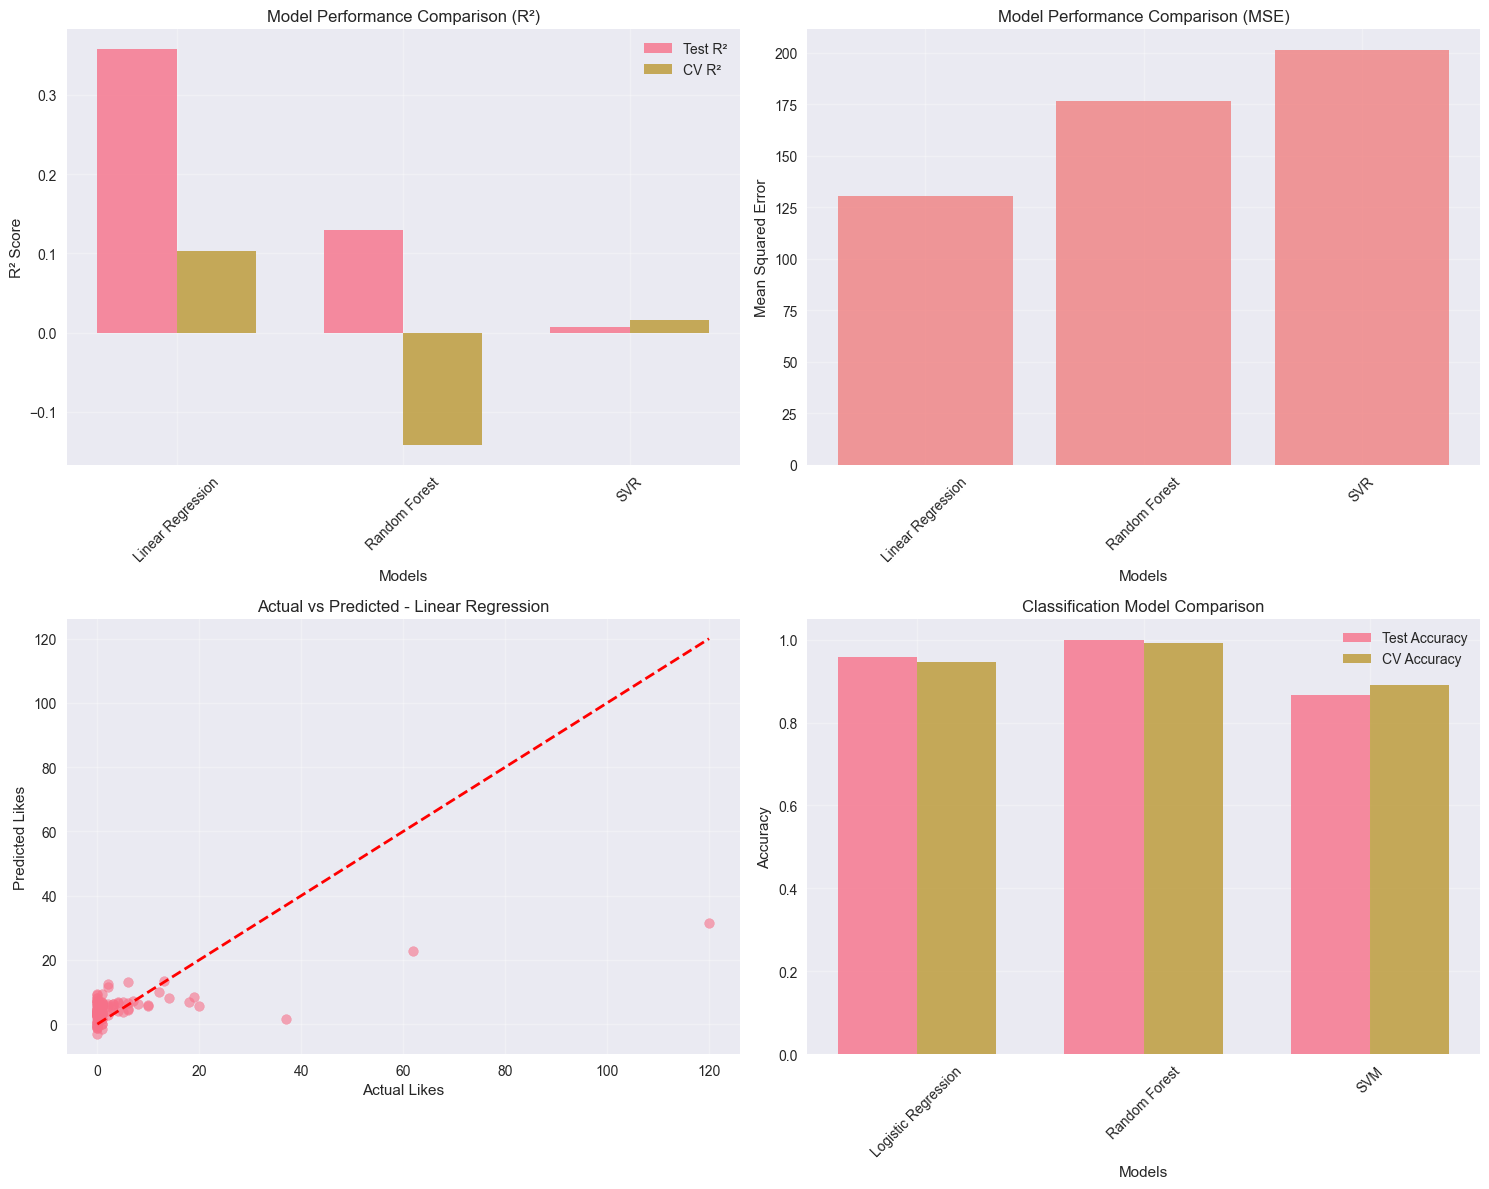


Best Regression Model: Linear Regression (R² = 0.3578)
Best Classification Model: Random Forest (Accuracy = 1.0000)


In [14]:
# Regression model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# R² comparison
model_names = list(results.keys())
r2_scores = [results[name]['R2'] for name in model_names]
cv_r2_scores = [results[name]['CV_R2_mean'] for name in model_names]

x_pos = np.arange(len(model_names))
width = 0.35

axes[0,0].bar(x_pos - width/2, r2_scores, width, label='Test R²', alpha=0.8)
axes[0,0].bar(x_pos + width/2, cv_r2_scores, width, label='CV R²', alpha=0.8)
axes[0,0].set_xlabel('Models')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_title('Model Performance Comparison (R²)')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(model_names, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# MSE comparison
mse_scores = [results[name]['MSE'] for name in model_names]
axes[0,1].bar(model_names, mse_scores, color='lightcoral', alpha=0.8)
axes[0,1].set_xlabel('Models')
axes[0,1].set_ylabel('Mean Squared Error')
axes[0,1].set_title('Model Performance Comparison (MSE)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# Actual vs Predicted for best regression model
best_reg_model = max(results.keys(), key=lambda k: results[k]['R2'])
best_reg_predictions = results[best_reg_model]['predictions']

axes[1,0].scatter(y_test, best_reg_predictions, alpha=0.6)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1,0].set_xlabel('Actual Likes')
axes[1,0].set_ylabel('Predicted Likes')
axes[1,0].set_title(f'Actual vs Predicted - {best_reg_model}')
axes[1,0].grid(True, alpha=0.3)

# Classification accuracy comparison
clf_names = list(clf_results.keys())
accuracies = [clf_results[name]['accuracy'] for name in clf_names]
cv_accuracies = [clf_results[name]['cv_mean'] for name in clf_names]

x_pos_clf = np.arange(len(clf_names))
axes[1,1].bar(x_pos_clf - width/2, accuracies, width, label='Test Accuracy', alpha=0.8)
axes[1,1].bar(x_pos_clf + width/2, cv_accuracies, width, label='CV Accuracy', alpha=0.8)
axes[1,1].set_xlabel('Models')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('Classification Model Comparison')
axes[1,1].set_xticks(x_pos_clf)
axes[1,1].set_xticklabels(clf_names, rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Regression Model: {best_reg_model} (R² = {results[best_reg_model]['R2']:.4f})")
print(f"Best Classification Model: {best_clf_model} (Accuracy = {clf_results[best_clf_model]['accuracy']:.4f})")